# nanoGPT walkthrough

Character-level GPT on Tiny Shakespeare, in the style of [karpathy/nanoGPT](https://github.com/karpathy/nanoGPT).

Experiment 001 uses a separate module per attention head, ReLU, and an untied output layer, with a fixed learning rate. This model uses one batched query/key/value projection, GELU, tied token and output weights, linear warmup, and a cosine decay. Gradient clipping is 1.0.

The cells below train the laptop preset for 400 steps. The full 2000-step run is `uv run python -m src.train --preset laptop`, and its numbers are in the experiment README.

In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

HERE = Path.cwd()
EXPERIMENT = HERE if (HERE / "src").exists() else HERE.parent
if str(EXPERIMENT) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT))

from src.sample import continue_prompt
from src.train import CharTokenizer, load_text, split_data, train, DEFAULT_DATA

text = load_text(DEFAULT_DATA)
tokenizer = CharTokenizer.from_text(text)
encoded = torch.tensor(tokenizer.encode(text), dtype=torch.long)
train_ids, val_ids = split_data(encoded)
uniform_loss = math.log(tokenizer.vocab_size)

print(f"characters: {len(text):,}")
print(f"vocab size: {tokenizer.vocab_size}")
print(f"train tokens: {len(train_ids):,}  val tokens: {len(val_ids):,}")
print(f"uniform next-character loss ln(vocab): {uniform_loss:.4f}")
print(text[:200])

characters: 1,115,394
vocab size: 65
train tokens: 1,003,854  val tokens: 111,540
uniform next-character loss ln(vocab): 4.1744
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


The file is the same Tiny Shakespeare text as experiment 001: 1,115,394 characters, vocabulary 65, split into 1,003,854 train tokens and 111,540 validation tokens. A model with no preferences among characters scores `ln(65)` = 4.17.

In [2]:
result = train(preset="laptop", max_iters=400, tag="gpt-walkthrough")
print(f"parameters: {result['num_parameters']:,}")
print(f"device: {result['device']}")
print(f"elapsed: {result['elapsed_seconds']:.1f}s")
for row in result["history"]:
    print(
        f"step {row['step']}: train {row['train_loss']:.4f}  "
        f"val {row['val_loss']:.4f}  lr {row['lr']:.6f}"
    )

model gpt  preset laptop  device mps  parameters 809,856  steps 400  lr 0.001 -> 0.0001


step 0: train loss 4.2088, val loss 4.2026, lr 0.000010


step 200: train loss 2.4648, val loss 2.4920, lr 0.000775


step 399: train loss 2.3482, val loss 2.3556, lr 0.000100
wrote /Users/akashchauhan/Development/ai-models-learning/experiments/language/002-nanogpt/runs/gpt-walkthrough.pt  (6.3s)
parameters: 809,856
device: mps
elapsed: 6.3s
step 0: train 4.2088  val 4.2026  lr 0.000010
step 200: train 2.4648  val 2.4920  lr 0.000775
step 399: train 2.3482  val 2.3556  lr 0.000100


This run has 809,856 parameters and trained on MPS in 6.3 seconds. Step 0 validation loss is 4.20, essentially `ln(65)`, because the output layer starts near zero. By step 399 validation loss is 2.36 and training loss is 2.35. The cosine is stretched across the 400 steps of this call, so the learning rate is already at its floor of 1e-4 by the last step. The full 2000-step run keeps a higher rate for longer.

In [3]:
sample, _ = continue_prompt(
    result["checkpoint_path"],
    prompt="ROMEO:",
    max_new_tokens=200,
)
print(sample)

ROMEO:
haysnteerellos, foth I je.
A
Whishe ing qut you.
Wid nod I goue se thit he dadeveren. crung is
Der thist asthetHeiet havenuke gor he ghaciseWhe s mimerdnd sn
Tenoure lomNath u iis fond esonig,
What.



At 400 steps the continuation is still character fragments with a few word-shaped pieces. The loss, 2.36 against a uniform 4.17, is the clear result of this short run. The 2000-step sample is in the experiment README.

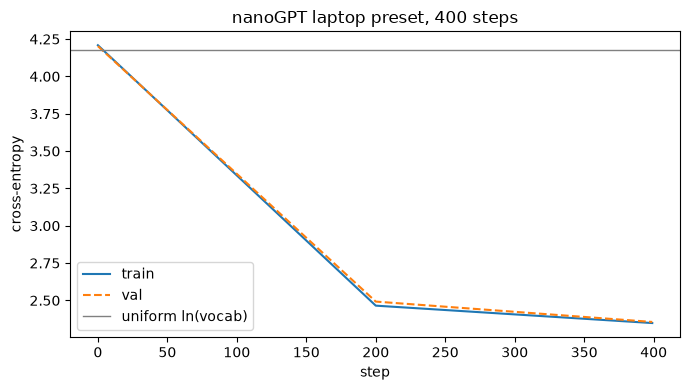

final val 2.3556  train 2.3482  uniform 4.1744


In [4]:
steps = [row["step"] for row in result["history"]]
train_loss = [row["train_loss"] for row in result["history"]]
val_loss = [row["val_loss"] for row in result["history"]]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps, train_loss, label="train")
ax.plot(steps, val_loss, linestyle="--", label="val")
ax.axhline(uniform_loss, color="gray", linewidth=1, label="uniform ln(vocab)")
ax.set_xlabel("step")
ax.set_ylabel("cross-entropy")
ax.set_title("nanoGPT laptop preset, 400 steps")
ax.legend()
fig.tight_layout()
plt.show()

end = result["history"][-1]
print(
    f"final val {end['val_loss']:.4f}  train {end['train_loss']:.4f}  "
    f"uniform {uniform_loss:.4f}"
)

Validation loss falls from 4.20 to 2.36, through the uniform line at 4.17. Training loss ends at 2.35, so the dashed validation line sits on the training line. The improvement shows up on the held-out tail of the plays.

## Summary

Tiny Shakespeare is 1,115,394 characters with a vocabulary of 65, so an uninformed next-character model scores 4.17. In 400 steps on MPS the 809,856-parameter nanoGPT falls from validation loss 4.20 to 2.36. The sample is still fragments. The full laptop checkpoint is `runs/gpt-laptop.pt`. The `shakespeare` preset (6 layers, 384-d, block 256, 5000 steps) matches upstream `train_shakespeare_char.py` and is the GPU configuration.